In [13]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

In [14]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['target_instances', 'd', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['target_instances', 'd'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['target_instances', 'd', 'method', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, topk_df




In [15]:
data_gaussian = pd.read_csv('results/gaussian.csv')
data_slash = pd.read_csv('results/slash.csv')
data_t= pd.read_csv('results/t.csv')

# Here we make final vizes!

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27760\1774229940.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LS_data_gaussian['method'] = 'LS'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27760\1774229940.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LAD_data_gaussian['method'] = 'LAD'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27760\1774229940.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

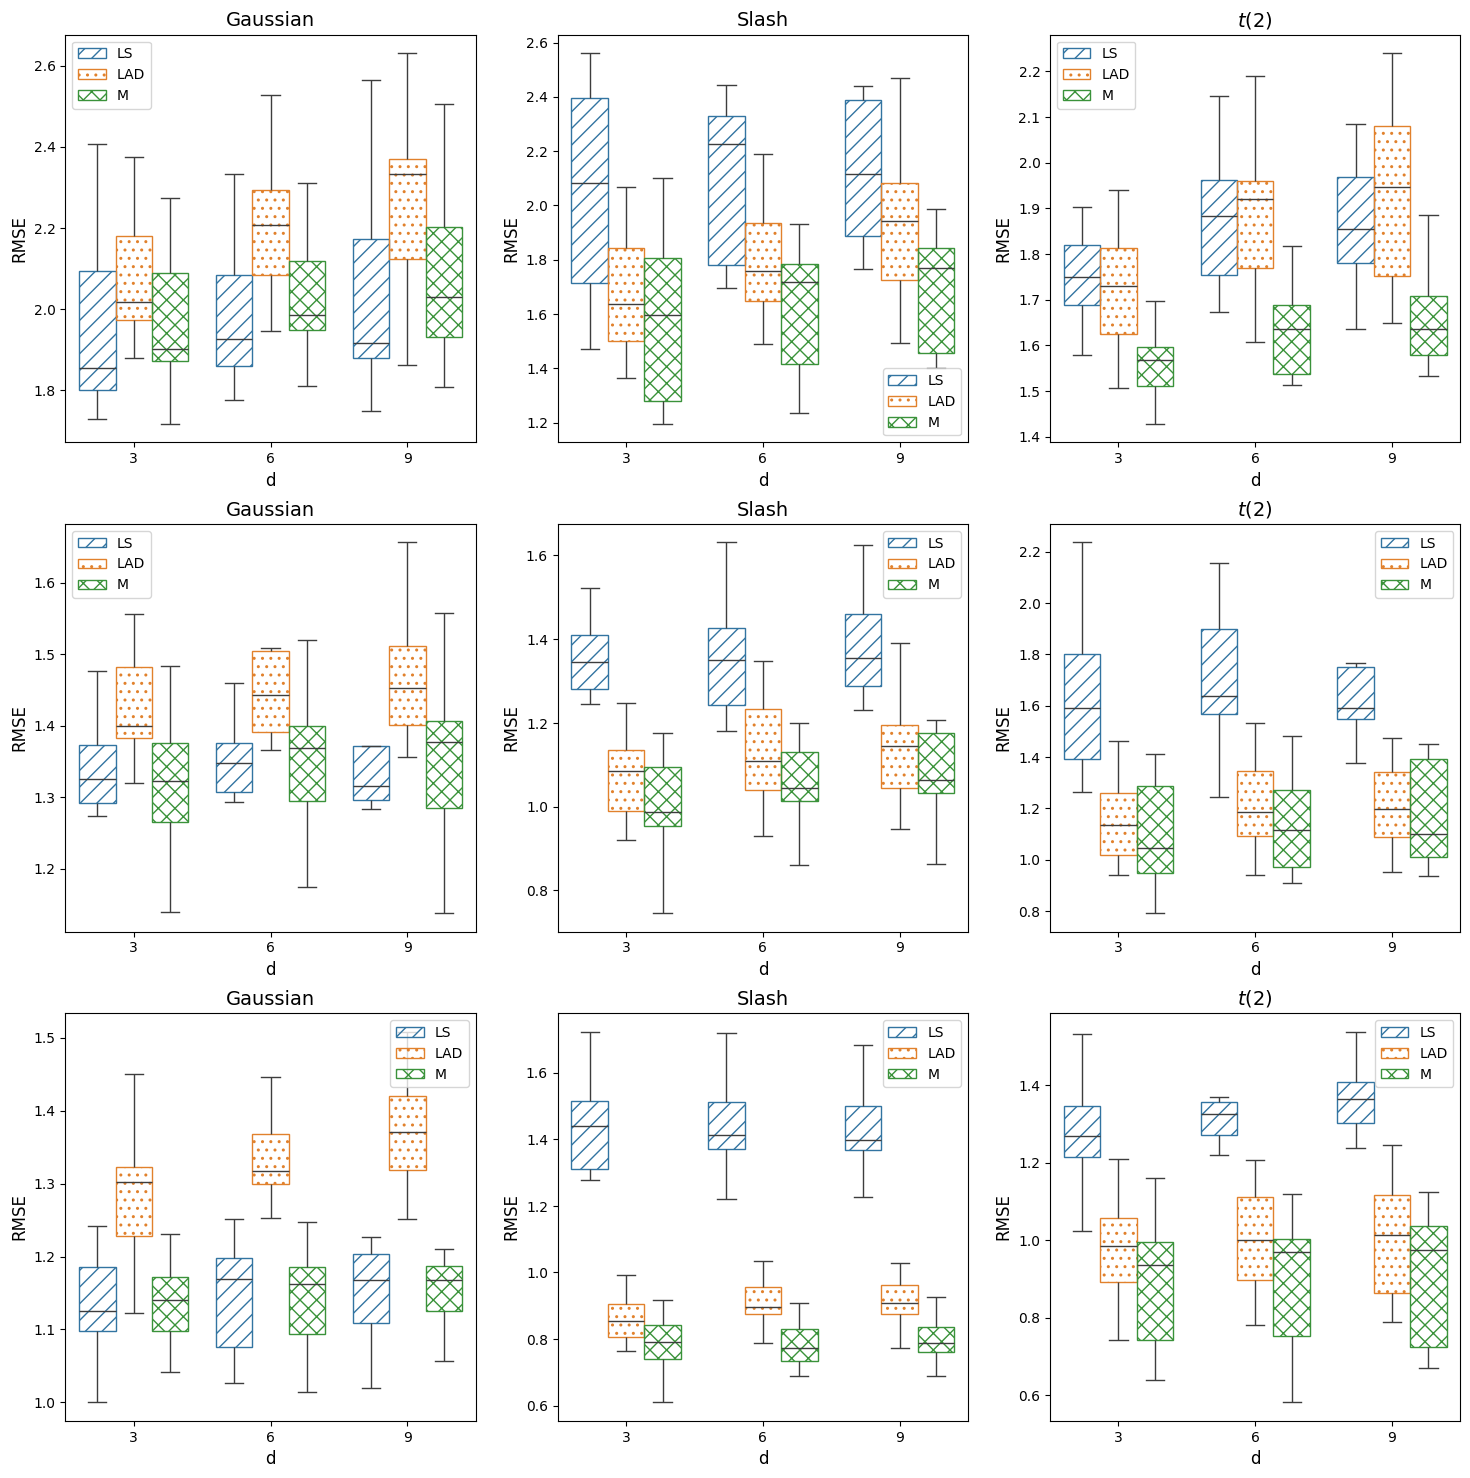

In [16]:

plt.figure(figsize = (18,18))
config_cols = ['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k']
import matplotlib as mpl
# Here we find the optimal settings (top5x5 = 25 total RMSEs)
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']
LS_data_gaussian['method'] = 'LS'
LAD_data_gaussian['method'] = 'LAD'
Huber_data_gaussian['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
    config_cols, k=25
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
    config_cols, k=25
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
    config_cols, k=25
)

i = 1

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])

for target_instances in [100, 300, 500]:
    plt.subplot(3,3,i)
    ax = sns.boxplot(x='d', y='rmse', hue='method', data=df[df['target_instances'] == target_instances], showfliers=False)
    plt.title('Gaussian', fontsize = 14)
    plt.ylabel('RMSE', fontsize=12)
    plt.xlabel('d', fontsize=12)
    # hatches must equal the number of hues (3 in this case)
    hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        fc = patch.get_facecolor()
        patch.set_edgecolor(fc)
        patch.set_facecolor('none')

    l = ax.legend()
    hatches_in_plot = ['//', '..', 'xx']
    for lp, hatch in zip(l.get_patches(), hatches_in_plot):
        lp.set_hatch(hatch)
        fc = lp.get_facecolor()
        lp.set_edgecolor(fc)
        lp.set_facecolor('none')
    i += 3



i = 2

# Here we find the optimal settings
LS_data_slash = data_slash[data_slash['method'] == 'LSTransferTreeBoost']
LAD_data_slash = data_slash[data_slash['method'] == 'LADTransferTreeBoost']
Huber_data_slash = data_slash[data_slash['method'] == 'MTransferTreeBoost']
LS_data_slash['method'] = 'LS'
LAD_data_slash['method'] = 'LAD'
Huber_data_slash['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_slash,
    config_cols, k=25
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_slash,
    config_cols, k=25
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_slash,
    config_cols, k=25
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
for target_instances in [100, 300, 500]:
    plt.subplot(3,3,i)
    ax = sns.boxplot(x='d', y='rmse', hue='method', data=df[df['target_instances'] == target_instances], showfliers=False)
    plt.title('Slash', fontsize = 14)
    plt.ylabel('RMSE', fontsize=12)
    plt.xlabel('d', fontsize=12)
    # hatches must equal the number of hues (3 in this case)
    hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        fc = patch.get_facecolor()
        patch.set_edgecolor(fc)
        patch.set_facecolor('none')

    l = ax.legend()
    hatches_in_plot = ['//', '..', 'xx']
    for lp, hatch in zip(l.get_patches(), hatches_in_plot):
        lp.set_hatch(hatch)
        fc = lp.get_facecolor()
        lp.set_edgecolor(fc)
        lp.set_facecolor('none')
    i += 3


i = 3
# Here we find the optimal settings
LS_data_t = data_t[data_t['method'] == 'LSTransferTreeBoost']
LAD_data_t = data_t[data_t['method'] == 'LADTransferTreeBoost']
Huber_data_t = data_t[data_t['method'] == 'MTransferTreeBoost']
LS_data_t['method'] = 'LS'
LAD_data_t['method'] = 'LAD'
Huber_data_t['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_t,
    config_cols, k=25
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_t,
    config_cols, k=25
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_t,
    config_cols, k=25
)

# create new df for viz
df = pd.concat([best_LS, best_LAD])
df = pd.concat([df, best_Huber])
for target_instances in [100, 300, 500]:
    plt.subplot(3,3,i)
    ax = sns.boxplot(x='d', y='rmse', hue='method', data=df[df['target_instances'] == target_instances], showfliers=False)
    plt.title('$t(2)$', fontsize = 14)
    plt.ylabel('RMSE', fontsize=12)
    plt.xlabel('d', fontsize=12)
    # hatches must equal the number of hues (3 in this case)
    hatches = ['//', '//', '//', '..', '..', '..', 'xx','xx','xx']
    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # the number of patches should be evenly divisible by the number of hatches
    h = hatches * (len(patches) // len(hatches))
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        fc = patch.get_facecolor()
        patch.set_edgecolor(fc)
        patch.set_facecolor('none')

    l = ax.legend()
    hatches_in_plot = ['//', '..', 'xx']
    for lp, hatch in zip(l.get_patches(), hatches_in_plot):
        lp.set_hatch(hatch)
        fc = lp.get_facecolor()
        lp.set_edgecolor(fc)
        lp.set_facecolor('none')
    i += 3

plt.subplots_adjust(hspace=0.2)  # increase horizontal spacing
plt.savefig('vizes/ls_lad_huber.png', bbox_inches = 'tight', pad_inches = 0.05, dpi = 300)


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27760\129447564.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LS_data_gaussian['method'] = 'LS'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27760\129447564.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LAD_data_gaussian['method'] = 'LAD'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27760\129447564.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

mae                 0.998935
val_mae             0.995912
val_rmse            0.995099
avg_rmse            0.930995
avg_mae             0.930854
m_0                 0.379912
d                   0.247267
k                  -0.243702
Unnamed: 0          0.236866
source_tree_size   -0.069818
v                  -0.041742
target_tree_size    0.038493
target_instances         NaN
n_seeds                  NaN
seed                     NaN
epochs                   NaN
Name: rmse, dtype: float64


<Axes: xlabel='target_instances', ylabel='avg_rmse'>

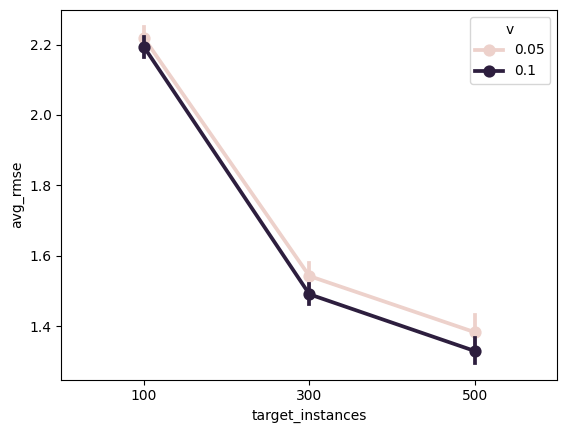

In [64]:
LS_data_gaussian = data_gaussian[data_gaussian['method'] == 'LSTransferTreeBoost']
LAD_data_gaussian = data_gaussian[data_gaussian['method'] == 'LADTransferTreeBoost']
Huber_data_gaussian = data_gaussian[data_gaussian['method'] == 'MTransferTreeBoost']
LS_data_gaussian['method'] = 'LS'
LAD_data_gaussian['method'] = 'LAD'
Huber_data_gaussian['method'] = 'M'

best_LS, best_LS_params = topk_per_d_per_method(
    LS_data_gaussian,
    config_cols, k=1000
)

best_LAD, best_LAD_params = topk_per_d_per_method(
    LAD_data_gaussian,
    config_cols, k=1000
)

best_Huber, best_Huber_params = topk_per_d_per_method(
    Huber_data_gaussian,
    config_cols, k=1000
)

best_Huber_params = best_Huber_params.iloc[list(range(0, len(best_Huber_params), 5))]
best_Huber_params_100 = best_Huber_params[best_Huber_params['target_instances'] == 100]

corr_with_rmse = (
    best_Huber_params_100
    .corr(numeric_only=True)['rmse']
    .drop('rmse')
    .sort_values(key=abs, ascending=False)
)

print(corr_with_rmse)

sns.pointplot(data = best_Huber_params, x = 'target_instances', y  = 'avg_rmse', hue = 'v')

# Final viz comes here!!!!
data = pd.read_csv('results/200_gaussian_6_optim.csv')
data_slash = pd.read_csv('results/200_slash_6_optim.csv')
# We remove one very weird result. As this did not happen in any other experiment, 
# we believe this is a numerical issue with the code. We remove the seed for both methods.
data = data[data['seed'] != 18] 
data_slash = data_slash[data_slash['seed'] != 18]
data['method'] = data['method'].replace("LSTransferTreeBoost", "LS")
data['method'] = data['method'].replace("LADTransferTreeBoost", "LAD")

data_slash['method'] = data_slash['method'].replace("LSTransferTreeBoost", "LS")
data_slash['method'] = data_slash['method'].replace("LADTransferTreeBoost", "LAD")

plt.figure(figsize = (14,10))

plt.subplot(2,2,1)
sns.boxplot(data = data, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,2)
sns.boxplot(data = data, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Gaussian', fontsize=16)

plt.subplot(2,2,3)
sns.boxplot(data = data_slash, x = 'method', y = 'rmse')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('RMSE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.subplot(2,2,4)
sns.boxplot(data = data_slash, x = 'method', y = 'mae')
plt.gca().set_xlabel(None)
plt.gca().set_ylabel('MAE', fontsize=14)
plt.gca().set_title('Slash', fontsize=16)

plt.savefig('vizes/ls-lad.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)







In [21]:
range(0, 5, len(best_Huber_params))

range(0, 5)

In [24]:
list(range(0,10,50))

[0]